In [1]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.1.2 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import pandas as pd
from tensorflow import keras
import os


In [3]:
# Define Data URL
MAIN_DIR = "D:\IMAGE2MASS"
IMAGE_DIR = MAIN_DIR + '\\' + 'imagery' + '\\' + 'realsense_overhead'
DISH_DATA_CAFE_1_FILE = MAIN_DIR + '\\' + "dish_metadata_cafe1.csv"
DISH_DATA_CAFE_2_FILE = MAIN_DIR + '\\' + "dish_metadata_cafe2.csv"

In [4]:
# To see the detail of the loading
# Please check the data_loading/loading_tf.ipynb file
# for more details
def load_dataset():
    try:
        cafe1 = pd.read_csv(DISH_DATA_CAFE_1_FILE, header=None, on_bad_lines='skip')
        cafe2 = pd.read_csv(DISH_DATA_CAFE_2_FILE, header=None, on_bad_lines='skip')        
        cafe1 = cafe1.iloc[:, :6]
        cafe2 = cafe2.iloc[:, :6]

        cafe1 = cafe1.dropna()
        cafe2 = cafe2.dropna()
        
        columns = {0: "dish_id", 1: "total_weight", 2: "total_calories", 3: "total_fat", 4: "total_carb", 5: "total_protein"}
        cafe1= cafe1.rename(columns=columns)
        cafe2= cafe2.rename(columns=columns)
        df = pd.concat([cafe1, cafe2], ignore_index=True)
        df["image_path"] = df["dish_id"].apply(lambda x: os.path.join(IMAGE_DIR, x))
        df["image_rgb_path"] = df["image_path"].apply(lambda x: os.path.join(x, "rgb.png"))
        df["image_depth_raw_path"] = df["image_path"].apply(lambda x: os.path.join(x, "depth_raw.png"))
        df["image_depth_color_path"] = df["image_path"].apply(lambda x: os.path.join(x, "depth_color.png"))
        return df
    except Exception as e:
        raise Exception(f"Error loading dataset: {e}")

In [5]:
# Vizualize some images
from PIL import Image
def visualize_image(image_path: str) -> None:
    img_matrix = np.asarray(Image.open(image_path))
    print(f"Image shape: {img_matrix.shape}")
    plt.imshow(img_matrix)

In [6]:
df = load_dataset() # Load the dataset
df.head()

,dish_id,total_weight,total_calories,total_fat,total_carb,total_protein,image_path,image_rgb_path,image_depth_raw_path,image_depth_color_path
0,dish_1561662216,300.794281,193.0,12.387489,28.218290,18.633970,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...
1,dish_1562688426,137.569992,88.0,8.256000,5.190000,10.297000,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...
2,dish_1561662054,419.438782,292.0,23.838249,26.351543,25.910593,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...
3,dish_1562008979,382.936646,290.0,22.224644,10.173570,35.345387,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...
4,dish_1560455030,20.590000,103.0,0.148000,4.625000,0.956000,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...,D:\IMAGE2MASS\imagery\realsense_overhead\dish_...


In [7]:
df.shape

(4583, 10)

In [8]:
# Splitting data into train, validation and test sets
# But first, shuffle the data
# But useless because of shuffle=True in tf.keras.utils.split_dataset
# So we can ignore this step and change the variable next
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [13]:
# create dataset tf Dataset for spliting and further processing
def load_and_preprocess(path, target) -> tuple:
    image = tf.io.read_file(path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    image = tf.cast(image, tf.float32) / 255.0
    return image, target

def create_tf_dataset(dataframe: pd.DataFrame) -> tf.data.Dataset:
    image_paths = dataframe["image_rgb_path"].values
    targets = dataframe[["total_fat", "total_carb", "total_protein"]].values.astype(np.float32)

    # Create a TensorFlow dataset
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, targets))

    # Map the loading and preprocessing function to the dataset
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset

def split_dataset(dataset: tf.data.Dataset, train_size=0.7, val_size=0.15, test_size=0.15) -> tuple:
    assert train_size + val_size + test_size == 1.0, "Train, validation and test sizes must sum to 1.0"

    total_size = len(dataset)
    train_size = int(total_size * train_size)
    val_size = int(total_size * val_size)

    train_dataset = dataset.take(train_size)
    val_dataset = dataset.skip(train_size).take(val_size)
    test_dataset = dataset.skip(train_size + val_size)

    return train_dataset, val_dataset, test_dataset

In [14]:
dataset = create_tf_dataset(df_shuffled)

Image shape: [[[0.3053221  0.26610643 0.26162463]
  [0.32324928 0.2762705  0.26050422]
  [0.33081234 0.26862746 0.26638657]
  ...
  [0.         0.02352941 0.        ]
  [0.11396731 0.12405127 0.11004525]
  [0.35742363 0.32100907 0.27899227]]

 [[0.3057223  0.27042818 0.24521808]
  [0.31064427 0.27535015 0.2557423 ]
  [0.3156863  0.27703083 0.26078433]
  ...
  [0.         0.02352941 0.        ]
  [0.1083253  0.11660846 0.10320272]
  [0.35686344 0.3254909  0.27843207]]

 [[0.30588236 0.2784314  0.24705882]
  [0.31008402 0.2747899  0.24733894]
  [0.3112845  0.2827131  0.2530212 ]
  ...
  [0.         0.02136867 0.        ]
  [0.10452399 0.11208684 0.09892119]
  [0.350421   0.3268916  0.2759112 ]]

 ...

 [[0.7058423  0.70192075 0.70192075]
  [0.702401   0.6984794  0.6984794 ]
  [0.70428175 0.70428175 0.70428175]
  ...
  [0.23725586 0.22156958 0.18627547]
  [0.28179285 0.26358548 0.22937182]
  [0.32633105 0.29103693 0.2714291 ]]

 [[0.7058824  0.7019608  0.7019608 ]
  [0.70504206 0.7011205 

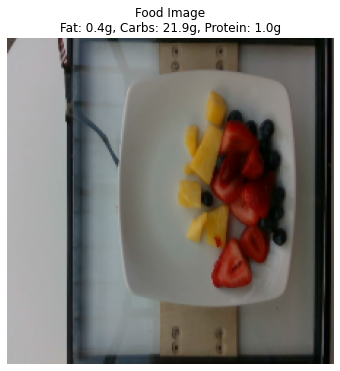

In [15]:
dataset.enumerate(start=5)
for image, target in dataset.as_numpy_iterator():
    print(f"Image shape: {image}, Target: {target}")
    print(len(target))
    print(image)
    plt.figure(figsize=(8, 6))
    plt.imshow(image)  # Convertir tensor en numpy pour matplotlib
    plt.title(f"Food Image\nFat: {target[0]:.1f}g, Carbs: {target[1]:.1f}g, Protein: {target[2]:.1f}g")
    plt.axis('off')
    plt.show()
    break

In [16]:
# Now doing the split
train_dataset, val_dataset, test_dataset = split_dataset(dataset)

In [20]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

3208
687
688


In [23]:
train_dataset

<TakeDataset element_spec=(TensorSpec(shape=(224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(3,), dtype=tf.float32, name=None))>